jitter seed = 2452435503


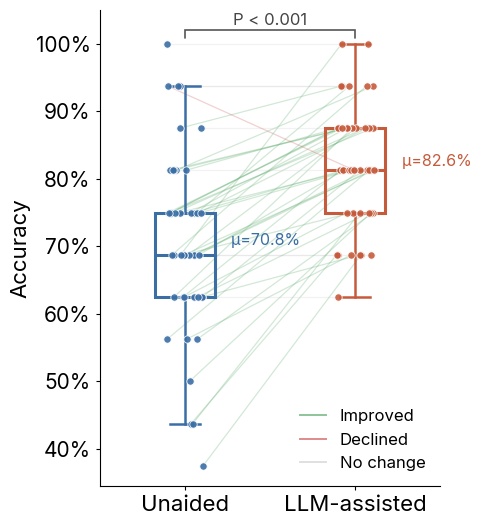

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy import stats

%matplotlib inline

# 'accuracy' -> per-participant proportion correct (0-1)
# 'count'    -> per-participant number of correct answers (0-n_q)
METRIC = 'accuracy'

df = pd.read_csv("../results/reader_study/responses.csv")

n_q = df.groupby('pid').size().max()  # questions per participant (16)

agg_fn = 'mean' if METRIC == 'accuracy' else 'sum'
acc = df.groupby('pid').agg(
    pre=('initial_correct', agg_fn),
    post=('final_correct', agg_fn),
).reset_index()

pre = acc['pre'].values
post = acc['post'].values

stat, p = stats.wilcoxon(post, pre, alternative='two-sided')
p_str = f"P = {p:.3f}" if p >= 0.001 else "P < 0.001"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter Variable", "Inter", "Helvetica Neue", "Arial", "DejaVu Sans"],
    'font.size': 15,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
})

fig, ax = plt.subplots(figsize=(5, 5.5))

# ── Colour scheme (unaided vs LLM-assisted) ─ colourblind-safe, ≥3:1 on white ──
# Pick one key below (validated with the data-viz palette checker). (unaided, LLM).
PALETTES = {
    'slate_terracotta': ('#3b6ea5', '#c65b3c'),  # muted slate-blue + terracotta (soft, publication)
    'teal_orange':      ('#1b9e77', '#d95f02'),  # teal + burnt-orange (ColorBrewer Dark2, editorial)
    'blue_orange':      ('#2a78d6', '#eb6834'),  # crisp blue + orange (vivid, classic)
    'blue_red':         ('#256abf', '#e34948'),  # blue + red (strong, diverging feel)
    'plum_teal':        ('#5b4b8a', '#2e9e8f'),  # muted plum + teal (elegant, low-key)
    'mulberry_teal':    ('#8c5383', '#2f9e8f'),  # mulberry + teal (sophisticated)
}
PALETTE = 'slate_terracotta'   # <- change this to any key above

PRE_COL, POST_COL = PALETTES[PALETTE]
LINE_UP   = '#5FAD6F'   # improved  (paired-line colour, independent of the palette)
LINE_DOWN = '#D05A5A'   # declined
LINE_SAME = "#D3D3D3"   # no change

bp = ax.boxplot(
    [pre, post],
    positions=[1, 2],
    widths=0.35,
    patch_artist=True,
    notch=False,
    medianprops=dict(linewidth=2.2),
    whiskerprops=dict(linestyle='-', linewidth=1.8),
    capprops=dict(linewidth=1.8),
    flierprops=dict(marker='none'),  # hide fliers — individual points shown via scatter
    boxprops=dict(linewidth=2.2),
    zorder=3,
)

colors = [PRE_COL, POST_COL]
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor('none')
    patch.set_edgecolor(col)

for whisker, col in zip(bp['whiskers'], [PRE_COL, PRE_COL, POST_COL, POST_COL]):
    whisker.set_color(col)

for cap, col in zip(bp['caps'], [PRE_COL, PRE_COL, POST_COL, POST_COL]):
    cap.set_color(col)

for median, col in zip(bp['medians'], colors):
    median.set_color(col)

# Random jitter each run — re-run until you get a clean layout, then pin the
# printed seed below to reproduce it.
seed = np.random.SeedSequence().entropy % (2**32)
# seed = 42  # <- uncomment and set to a printed seed to lock a layout you like
rng = np.random.default_rng(seed)
print(f"jitter seed = {seed}")
jitter_pre  = rng.uniform(-0.11, 0.11, len(pre))
jitter_post = rng.uniform(-0.11, 0.11, len(post))

for i in range(len(pre)):
    xp = 1 + jitter_pre[i]
    xq = 2 + jitter_post[i]
    dy = post[i] - pre[i]
    lc = LINE_UP if dy > 0 else (LINE_DOWN if dy < 0 else LINE_SAME)
    ax.plot([xp, xq], [pre[i], post[i]],
            color=lc, alpha=0.28, linewidth=0.9, zorder=2)

ax.scatter(1 + jitter_pre,  pre,  color=PRE_COL,  s=28, zorder=4,
           edgecolors='white', linewidths=0.6, alpha=0.9)
ax.scatter(2 + jitter_post, post, color=POST_COL, s=28, zorder=4,
           edgecolors='white', linewidths=0.6, alpha=0.9)

# Axis geometry depends on the metric (proportion vs. count).
y_max = max(pre.max(), post.max())
y_min = min(pre.min(), post.min())
if METRIC == 'accuracy':
    y_lo, y_hi = y_min - 0.03, 1.05
    y_top   = 1.02
    y_tick  = y_top - 0.012     # depth of the bracket's downward ticks
    txt_off = 0.004
else:
    yr = max(y_max - y_min, 1)
    y_lo, y_hi = y_min - 0.06 * yr, y_max + 0.18 * yr
    y_top   = y_max + 0.10 * yr
    y_tick  = y_top - 0.025 * yr
    txt_off = 0.012 * yr

ax.set_xlim(0.5, 2.5)
ax.set_ylim(y_lo, y_hi)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Unaided', 'LLM-assisted'], fontsize=16)
if METRIC == 'accuracy':
    ax.set_ylabel('Accuracy', fontsize=16)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
else:
    ax.set_ylabel(f'Number of correct answers (of {n_q})', fontsize=16)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(axis='both', length=3, width=0.8)
#ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)

# Significance bracket — single continuous path so the corners join cleanly.
ax.plot([1, 1, 2, 2], [y_tick, y_top, y_top, y_tick],
        color='#555555', lw=1.2, solid_capstyle='round',
        solid_joinstyle='miter', clip_on=False, zorder=5)
ax.text(1.5, y_top + txt_off, f'{p_str}', ha='center', va='bottom',
        fontsize=12, color='#444444')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=LINE_UP,   alpha=0.7, lw=1.4, label='Improved'),
    Line2D([0], [0], color=LINE_DOWN, alpha=0.7, lw=1.4, label='Declined'),
    Line2D([0], [0], color=LINE_SAME, alpha=0.7, lw=1.4, label='No change'),
]
ax.legend(handles=legend_elements, fontsize=12, frameon=False,
          loc='lower right', handlelength=1.6)

mfmt = '{:.1%}' if METRIC == 'accuracy' else '{:.1f}'
for x, vals, col in [(1, pre, PRE_COL), (2, post, POST_COL)]:
    m = np.mean(vals)
    ax.text(x + 0.22, m, f'  μ={mfmt.format(m)}', va='center', fontsize=11.5,
            color=col, fontweight='bold')

fig.tight_layout()
fname = 'accuracy_boxplot' if METRIC == 'accuracy' else 'correct_count_boxplot'
fig.savefig(f'../plots/reader_study/{fname}.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

palette = slate_terracotta | n=46 | unaided μ=73.2% -> LLM-assisted μ=83.9% | P < 0.001


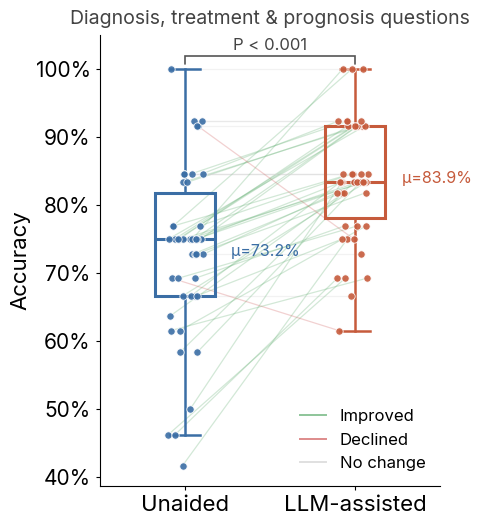

In [2]:
# ── Physician improvement restricted to diagnosis / treatment / prognosis ──────
# Filtering to a subset of question types leaves each physician with a variable
# number of questions (11-13), so per-participant ACCURACY (proportion correct)
# is used here rather than the raw count metric of the cell above.

QTYPES = ['diagnosis', 'treatment', 'prognosis']

df_dtp = df[df['question_type'].isin(QTYPES)].copy()

acc = df_dtp.groupby('pid').agg(
    pre=('initial_correct', 'mean'),
    post=('final_correct', 'mean'),
).reset_index()

pre = acc['pre'].values
post = acc['post'].values

stat, p = stats.wilcoxon(post, pre, alternative='two-sided')
p_str = f"P = {p:.3f}" if p >= 0.001 else "P < 0.001"

fig, ax = plt.subplots(figsize=(5, 5.5))

# ── Colour scheme (unaided vs LLM-assisted) ─ colourblind-safe, ≥3:1 on white ──
# Pick one key below (validated with the data-viz palette checker). (unaided, LLM).
PALETTES = {
    'slate_terracotta': ('#3b6ea5', '#c65b3c'),  # muted slate-blue + terracotta (soft, publication)
    'teal_orange':      ('#1b9e77', '#d95f02'),  # teal + burnt-orange (ColorBrewer Dark2, editorial)
    'blue_orange':      ('#2a78d6', '#eb6834'),  # crisp blue + orange (vivid, classic)
    'blue_red':         ('#256abf', '#e34948'),  # blue + red (strong, diverging feel)
    'plum_teal':        ('#5b4b8a', '#2e9e8f'),  # muted plum + teal (elegant, low-key)
    'mulberry_teal':    ('#8c5383', '#2f9e8f'),  # mulberry + teal (sophisticated)
}
PALETTE = 'slate_terracotta'   # <- change this to any key above

PRE_COL, POST_COL = PALETTES[PALETTE]
LINE_UP   = '#5FAD6F'   # improved  (paired-line colour, independent of the palette)
LINE_DOWN = '#D05A5A'   # declined
LINE_SAME = "#D3D3D3"   # no change

bp = ax.boxplot(
    [pre, post],
    positions=[1, 2],
    widths=0.35,
    patch_artist=True,
    notch=False,
    medianprops=dict(linewidth=2.2),
    whiskerprops=dict(linestyle='-', linewidth=1.8),
    capprops=dict(linewidth=1.8),
    flierprops=dict(marker='none'),
    boxprops=dict(linewidth=2.2),
    zorder=3,
)

colors = [PRE_COL, POST_COL]
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor('none')
    patch.set_edgecolor(col)
for whisker, col in zip(bp['whiskers'], [PRE_COL, PRE_COL, POST_COL, POST_COL]):
    whisker.set_color(col)
for cap, col in zip(bp['caps'], [PRE_COL, PRE_COL, POST_COL, POST_COL]):
    cap.set_color(col)
for median, col in zip(bp['medians'], colors):
    median.set_color(col)

seed = 42
rng = np.random.default_rng(seed)
jitter_pre  = rng.uniform(-0.11, 0.11, len(pre))
jitter_post = rng.uniform(-0.11, 0.11, len(post))

for i in range(len(pre)):
    xp = 1 + jitter_pre[i]
    xq = 2 + jitter_post[i]
    dy = post[i] - pre[i]
    lc = LINE_UP if dy > 0 else (LINE_DOWN if dy < 0 else LINE_SAME)
    ax.plot([xp, xq], [pre[i], post[i]],
            color=lc, alpha=0.28, linewidth=0.9, zorder=2)

ax.scatter(1 + jitter_pre,  pre,  color=PRE_COL,  s=28, zorder=4,
           edgecolors='white', linewidths=0.6, alpha=0.9)
ax.scatter(2 + jitter_post, post, color=POST_COL, s=28, zorder=4,
           edgecolors='white', linewidths=0.6, alpha=0.9)

y_min = min(pre.min(), post.min())
y_lo, y_hi = y_min - 0.03, 1.05
y_top, y_tick, txt_off = 1.02, 1.008, 0.004

ax.set_xlim(0.5, 2.5)
ax.set_ylim(y_lo, y_hi)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Unaided', 'LLM-assisted'], fontsize=16)
ax.set_ylabel('Accuracy', fontsize=16)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.tick_params(axis='both', length=3, width=0.8)
ax.set_axisbelow(True)

ax.plot([1, 1, 2, 2], [y_tick, y_top, y_top, y_tick],
        color='#555555', lw=1.2, solid_capstyle='round',
        solid_joinstyle='miter', clip_on=False, zorder=5)
ax.text(1.5, y_top + txt_off, f'{p_str}', ha='center', va='bottom',
        fontsize=12, color='#444444')
ax.set_title('Diagnosis, treatment & prognosis questions',
             fontsize=14, color='#444444', pad=8)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=LINE_UP,   alpha=0.7, lw=1.4, label='Improved'),
    Line2D([0], [0], color=LINE_DOWN, alpha=0.7, lw=1.4, label='Declined'),
    Line2D([0], [0], color=LINE_SAME, alpha=0.7, lw=1.4, label='No change'),
]
ax.legend(handles=legend_elements, fontsize=12, frameon=False,
          loc='lower right', handlelength=1.6)

for x, vals, col in [(1, pre, PRE_COL), (2, post, POST_COL)]:
    m = np.mean(vals)
    ax.text(x + 0.22, m, f'  μ={m:.1%}', va='center', fontsize=11.5,
            color=col, fontweight='bold')

fig.tight_layout()
fig.savefig('../plots/reader_study/accuracy_boxplot_dtp.png', dpi=180,
            bbox_inches='tight', facecolor='white')
print(f"palette = {PALETTE} | n={len(pre)} | unaided μ={pre.mean():.1%} -> LLM-assisted μ={post.mean():.1%} | {p_str}")
plt.show()

palette = slate_terracotta  (#3b6ea5 / #c65b3c)
           q   n      pre     post    delta     d_lo     d_hi
epidemiology  41 0.658537 0.804878 0.146341 0.046512 0.263158
   prognosis  46 0.543478 0.847826 0.304348 0.177778 0.442361
   mechanism 132 0.621212 0.780303 0.159091 0.090909 0.231343
   treatment 153 0.738562 0.869281 0.130719 0.077419 0.187097
   diagnosis 364 0.752747 0.824176 0.071429 0.040541 0.103064


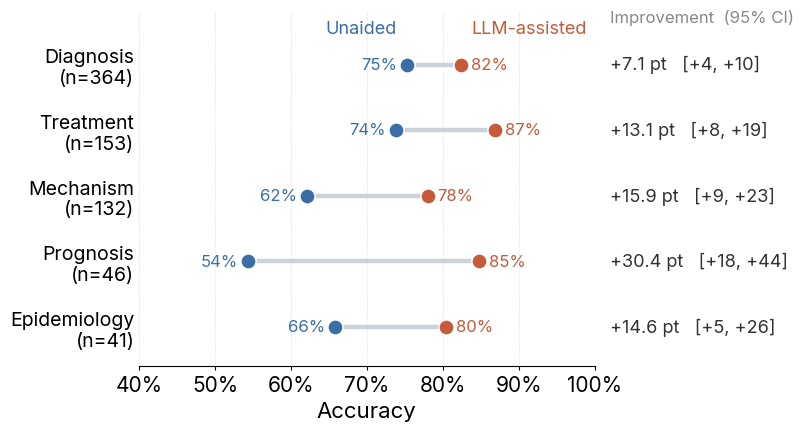

In [3]:
# ── Dumbbell: improvement by question type (ordered by n), textual CI on delta ─
# Clean connector-line dumbbell (no arrows). Rows ordered by sample size (high→low
# from the top). Uncertainty is reported as text: improvement (Δ pt) with a
# physician-clustered bootstrap 95% CI on the DIFFERENCE final−initial.

# ── Colour scheme ──────────────────────────────────────────────────────────────
# Pick one key below. Every pair is colourblind-safe and ≥3:1 contrast on white
# (checked with the data-viz palette validator: CVD ΔE ≥ 8, normal-vision ΔE ≥ 15).
# Each entry is (unaided, LLM-assisted).
PALETTES = {
    'slate_terracotta': ('#3b6ea5', '#c65b3c'),  # muted slate-blue + terracotta (soft, publication)
    'teal_orange':      ('#1b9e77', '#d95f02'),  # teal + burnt-orange (ColorBrewer Dark2, editorial)
    'blue_orange':      ('#2a78d6', '#eb6834'),  # crisp blue + orange (vivid, classic)
    'blue_red':         ('#256abf', '#e34948'),  # blue + red (strong, diverging feel)
    'plum_teal':        ('#5b4b8a', '#2e9e8f'),  # muted plum + teal (elegant, low-key)
    'mulberry_teal':    ('#8c5383', '#2f9e8f'),  # mulberry + teal (sophisticated)
}
PALETTE = 'slate_terracotta'   # <- change this to any key above

PRE_COL, POST_COL = PALETTES[PALETTE]
LINE_COL = '#CBD2DA'   # neutral connector (works with every scheme)

def clustered_delta_ci(sub, n=5000, seed=42):
    rng = np.random.default_rng(seed)
    pids = sub['pid'].unique()
    by_pid = {pid: sub.loc[sub['pid'] == pid, ['initial_correct', 'final_correct']].values
              for pid in pids}
    deltas = np.empty(n)
    for b in range(n):
        pick = rng.choice(pids, size=len(pids), replace=True)
        vals = np.concatenate([by_pid[p] for p in pick])
        deltas[b] = vals[:, 1].mean() - vals[:, 0].mean()
    return np.percentile(deltas, 2.5), np.percentile(deltas, 97.5)

order = ['diagnosis', 'treatment', 'prognosis', 'mechanism', 'epidemiology']
qtypes = [q for q in order if q in df['question_type'].unique()]

rows = []
for q in qtypes:
    sub = df[df['question_type'] == q]
    pre_m, post_m = sub['initial_correct'].mean(), sub['final_correct'].mean()
    d_lo, d_hi = clustered_delta_ci(sub)
    rows.append(dict(q=q, n=len(sub), pre=pre_m, post=post_m,
                     delta=post_m - pre_m, d_lo=d_lo, d_hi=d_hi))
# Order by n ascending so the largest-n type sits at the TOP of the axis.
res = pd.DataFrame(rows).sort_values('n', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.2, 4.6))
y = np.arange(len(res))

for i, r in res.iterrows():
    ax.plot([r['pre'], r['post']], [i, i], color=LINE_COL, lw=3.2,
            solid_capstyle='round', zorder=1)

ax.scatter(res['pre'],  y, color=PRE_COL,  s=120, zorder=3, edgecolors='white',
           linewidths=1.1)
ax.scatter(res['post'], y, color=POST_COL, s=120, zorder=3, edgecolors='white',
           linewidths=1.1)

# Value labels directly at each dot.
for i, r in res.iterrows():
    ax.text(r['pre'] - 0.013,  i, f"{r['pre']*100:.0f}%",  ha='right', va='center',
            fontsize=12, color=PRE_COL, fontweight='bold')
    ax.text(r['post'] + 0.013, i, f"{r['post']*100:.0f}%", ha='left', va='center',
            fontsize=12, color=POST_COL, fontweight='bold')

# Endpoint labels on the top row instead of a boxed legend.
top = len(res) - 1
ax.text(res.loc[top, 'pre'] - 0.013, top + 0.42, 'Unaided', ha='right', va='bottom',
        fontsize=13, color=PRE_COL, fontweight='bold')
ax.text(res.loc[top, 'post'] + 0.013, top + 0.42, 'LLM-assisted', ha='left', va='bottom',
        fontsize=13, color=POST_COL, fontweight='bold')

# Right-hand text column: improvement + CI.
x_txt = 1.02
ax.text(x_txt, len(res) - 0.4, 'Improvement  (95% CI)', va='bottom', ha='left',
        fontsize=12, color='#888888', style='italic', clip_on=False)
for i, r in res.iterrows():
    ax.text(x_txt, i,
            f"+{r['delta']*100:.1f} pt   [{r['d_lo']*100:+.0f}, {r['d_hi']*100:+.0f}]",
            va='center', ha='left', fontsize=13, color='#333333', clip_on=False)

ax.set_yticks(y)
ax.set_yticklabels([f"{r['q'].capitalize()}\n(n={r['n']})" for _, r in res.iterrows()],
                   fontsize=14)
ax.set_xlim(0.40, 1.0)
ax.set_ylim(-0.6, len(res) - 0.2)
ax.set_xlabel('Accuracy', fontsize=16)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.tick_params(axis='x', length=3, width=0.8)
ax.tick_params(axis='y', length=0)
for sp in ['left', 'top', 'right']:
    ax.spines[sp].set_visible(False)
ax.xaxis.grid(True, linestyle=':', linewidth=0.7, color='#DEDEDE', zorder=0)
ax.set_axisbelow(True)

#ax.set_title('Physician improvement by question type', fontsize=17,
#             color='#222222', pad=24, loc='left', x=0.0)

fig.subplots_adjust(right=0.62)
fig.savefig(f'../plots/reader_study/dumbbell_by_question_type.png', dpi=180,
            bbox_inches='tight', facecolor='white')
print(f"palette = {PALETTE}  ({PRE_COL} / {POST_COL})")
print(res[['q', 'n', 'pre', 'post', 'delta', 'd_lo', 'd_hi']].to_string(index=False))
plt.show()

palette = slate_terracotta
               cat   n      pre     post    delta      d_lo     d_hi
         Hair Nail   9 0.888889 1.000000 0.111111  0.000000 0.333333
             Other  30 0.900000 0.966667 0.066667  0.000000 0.151515
      Pigmentation  31 0.677419 0.806452 0.129032  0.000000 0.275862
Metabolic Systemic  91 0.703297 0.879121 0.175824  0.089888 0.261911
      Genetic Rare 102 0.705882 0.862745 0.156863  0.067961 0.252525
        Neoplastic 134 0.708955 0.731343 0.022388 -0.048951 0.096000
      Inflammatory 165 0.721212 0.824242 0.103030  0.057801 0.152047
        Infectious 174 0.660920 0.821839 0.160920  0.107950 0.213542


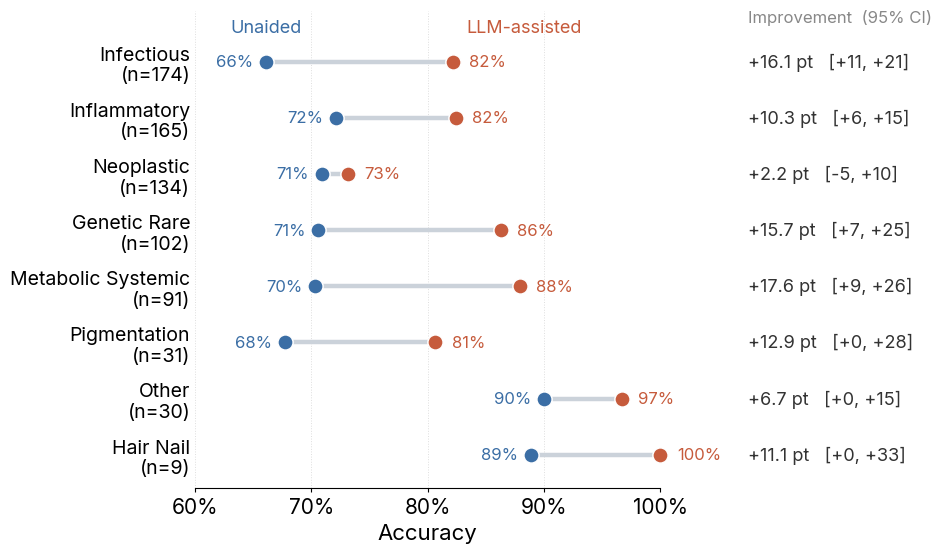

In [4]:
# ── Dumbbell: improvement by DISEASE CATEGORY (ordered by n), textual CI on delta
# Same design as the question-type dumbbell. Disease categories are taken from the
# cleaned mapping in results/question_categories_cleaned.csv (merged on question_id).

# ── Colour scheme ──────────────────────────────────────────────────────────────
PALETTES = {
    'slate_terracotta': ('#3b6ea5', '#c65b3c'),  # muted slate-blue + terracotta (soft, publication)
    'teal_orange':      ('#1b9e77', '#d95f02'),  # teal + burnt-orange (ColorBrewer Dark2, editorial)
    'blue_orange':      ('#2a78d6', '#eb6834'),  # crisp blue + orange (vivid, classic)
    'blue_red':         ('#256abf', '#e34948'),  # blue + red (strong, diverging feel)
    'plum_teal':        ('#5b4b8a', '#2e9e8f'),  # muted plum + teal (elegant, low-key)
    'mulberry_teal':    ('#8c5383', '#2f9e8f'),  # mulberry + teal (sophisticated)
}
PALETTE = 'slate_terracotta'   # <- change this to any key above

PRE_COL, POST_COL = PALETTES[PALETTE]
LINE_COL = '#CBD2DA'   # neutral connector

# Merge the cleaned disease-category labels onto the responses by question_id.
cat_map = (pd.read_csv('../results/question_categories_cleaned.csv')
           [['question_id', 'disease_category']]
           .rename(columns={'disease_category': 'disease_category_clean'}))
dfc = df.merge(cat_map, on='question_id', how='left')

def clustered_delta_ci(sub, n=5000, seed=42):
    rng = np.random.default_rng(seed)
    pids = sub['pid'].unique()
    by_pid = {pid: sub.loc[sub['pid'] == pid, ['initial_correct', 'final_correct']].values
              for pid in pids}
    deltas = np.empty(n)
    for b in range(n):
        pick = rng.choice(pids, size=len(pids), replace=True)
        vals = np.concatenate([by_pid[p] for p in pick])
        deltas[b] = vals[:, 1].mean() - vals[:, 0].mean()
    return np.percentile(deltas, 2.5), np.percentile(deltas, 97.5)

rows = []
for cat in dfc['disease_category_clean'].dropna().unique():
    sub = dfc[dfc['disease_category_clean'] == cat]
    pre_m, post_m = sub['initial_correct'].mean(), sub['final_correct'].mean()
    d_lo, d_hi = clustered_delta_ci(sub)
    rows.append(dict(cat=cat, n=len(sub), pre=pre_m, post=post_m,
                     delta=post_m - pre_m, d_lo=d_lo, d_hi=d_hi))
# Order by n ascending so the largest-n category sits at the TOP of the axis.
res = pd.DataFrame(rows).sort_values('n', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.8, 6.2))
y = np.arange(len(res))

for i, r in res.iterrows():
    ax.plot([r['pre'], r['post']], [i, i], color=LINE_COL, lw=3.2,
            solid_capstyle='round', zorder=1)

# clip_on=False so dots that land exactly on the 100% axis edge aren't clipped.
ax.scatter(res['pre'],  y, color=PRE_COL,  s=120, zorder=3, edgecolors='white',
           linewidths=1.1, clip_on=False)
ax.scatter(res['post'], y, color=POST_COL, s=120, zorder=3, edgecolors='white',
           linewidths=1.1, clip_on=False)

# Value labels directly at each dot (smaller value on the left, larger on the right).
for i, r in res.iterrows():
    left_val, left_col   = (r['pre'], PRE_COL) if r['pre'] <= r['post'] else (r['post'], POST_COL)
    right_val, right_col = (r['post'], POST_COL) if r['post'] >= r['pre'] else (r['pre'], PRE_COL)
    ax.text(min(r['pre'], r['post']) - 0.011, i, f"{left_val*100:.0f}%",
            ha='right', va='center', fontsize=12, color=left_col, fontweight='bold')
    ax.text(max(r['pre'], r['post']) + 0.014, i, f"{right_val*100:.0f}%",
            ha='left', va='center', fontsize=12, color=right_col, fontweight='bold', clip_on=False)

# Endpoint labels on the top row instead of a boxed legend. 'Unaided' is centred
# over its dot so it stays inside the axis when the x-range starts at 60%.
top = len(res) - 1
ax.text(res.loc[top, 'pre'], top + 0.45, 'Unaided', ha='center', va='bottom',
        fontsize=13, color=PRE_COL, fontweight='bold')
ax.text(res.loc[top, 'post'] + 0.011, top + 0.45, 'LLM-assisted', ha='left', va='bottom',
        fontsize=13, color=POST_COL, fontweight='bold')

# Right-hand text column: improvement + CI. Placed just clear of the 100% dot labels.
x_txt = 1.075
ax.text(x_txt, len(res) - 0.35, 'Improvement  (95% CI)', va='bottom', ha='left',
        fontsize=12, color='#888888', style='italic', clip_on=False)
for i, r in res.iterrows():
    ax.text(x_txt, i,
            f"{r['delta']*100:+.1f} pt   [{r['d_lo']*100:+.0f}, {r['d_hi']*100:+.0f}]",
            va='center', ha='left', fontsize=13, color='#333333', clip_on=False)

ax.set_yticks(y)
ax.set_yticklabels([f"{r['cat']}\n(n={r['n']})" for _, r in res.iterrows()], fontsize=14)
lo = min(res['pre'].min(), res['post'].min())
ax.set_xlim(max(0.0, np.floor(lo * 20) / 20 - 0.05), 1.0)  # one 5% step below the lowest dot
ax.set_ylim(-0.6, len(res) - 0.1)
ax.set_xlabel('Accuracy', fontsize=16)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.tick_params(axis='x', length=3, width=0.8)
ax.tick_params(axis='y', length=0)
for sp in ['left', 'top', 'right']:
    ax.spines[sp].set_visible(False)
ax.xaxis.grid(True, linestyle=':', linewidth=0.7, color='#DEDEDE', zorder=0)
ax.set_axisbelow(True)

#ax.set_title('Physician improvement by disease category', fontsize=17,
#             color='#222222', pad=26, loc='left', x=0.0)

fig.subplots_adjust(right=0.60)
fig.savefig('../plots/reader_study/dumbbell_by_disease_category.png', dpi=180,
            bbox_inches='tight', facecolor='white')
print(f"palette = {PALETTE}")
print(res[['cat', 'n', 'pre', 'post', 'delta', 'd_lo', 'd_hi']].to_string(index=False))
plt.show()

In [ ]:
# ── Stacked dumbbells: question type (top) + disease category (bottom) ─────────
# Both panels share one x-axis and one x-range, so rows line up vertically across
# the separator. Row height is identical in both panels (height_ratios == row
# counts, same y-padding). Improvement + CI are printed as a table below the figure.

PALETTES = {
    'slate_terracotta': ('#3b6ea5', '#c65b3c'),  # muted slate-blue + terracotta (soft, publication)
    'teal_orange':      ('#1b9e77', '#d95f02'),  # teal + burnt-orange (ColorBrewer Dark2, editorial)
    'blue_orange':      ('#2a78d6', '#eb6834'),  # crisp blue + orange (vivid, classic)
    'blue_red':         ('#256abf', '#e34948'),  # blue + red (strong, diverging feel)
    'plum_teal':        ('#5b4b8a', '#2e9e8f'),  # muted plum + teal (elegant, low-key)
    'mulberry_teal':    ('#8c5383', '#2f9e8f'),  # mulberry + teal (sophisticated)
}
PALETTE = 'slate_terracotta'   # <- change this to any key above

PRE_COL, POST_COL = PALETTES[PALETTE]
LINE_COL = '#CBD2DA'   # neutral connector

# ── Font sizes (single place to scale the whole figure) ────────────────────────
FS_ROW   = 20   # row labels (category + n)
FS_VAL   = 16   # the % value next to each dot
FS_LEGEND = 18  # 'Unaided' / 'LLM-assisted'
FS_XTICK = 21   # x tick labels
FS_XLAB  = 24   # 'Accuracy'
DOT_S    = 165  # dot area
SEP_COL  = '#8A929B'   # panel separator colour
SEP_LW   = 1.8         # panel separator width


def clustered_delta_ci(sub, n=5000, seed=42):
    rng = np.random.default_rng(seed)
    pids = sub['pid'].unique()
    by_pid = {pid: sub.loc[sub['pid'] == pid, ['initial_correct', 'final_correct']].values
              for pid in pids}
    deltas = np.empty(n)
    for b in range(n):
        pick = rng.choice(pids, size=len(pids), replace=True)
        vals = np.concatenate([by_pid[p] for p in pick])
        deltas[b] = vals[:, 1].mean() - vals[:, 0].mean()
    return np.percentile(deltas, 2.5), np.percentile(deltas, 97.5)


def summarise(frame, col, keys):
    """Per-group pre/post means + clustered bootstrap CI on the difference.
    Ordered by n ascending so the largest group sits at the TOP of the axis."""
    rows = []
    for k in keys:
        sub = frame[frame[col] == k]
        d_lo, d_hi = clustered_delta_ci(sub)
        rows.append(dict(label=k, n=len(sub),
                         pre=sub['initial_correct'].mean(),
                         post=sub['final_correct'].mean(),
                         delta=sub['final_correct'].mean() - sub['initial_correct'].mean(),
                         d_lo=d_lo, d_hi=d_hi))
    return pd.DataFrame(rows).sort_values('n', ascending=True).reset_index(drop=True)


# ── Panel A data: question type ────────────────────────────────────────────────
order = ['diagnosis', 'treatment', 'prognosis', 'mechanism', 'epidemiology']
qtypes = [q for q in order if q in df['question_type'].unique()]
res_q = summarise(df, 'question_type', qtypes)
res_q['label'] = res_q['label'].str.capitalize()

# ── Panel B data: disease category (cleaned mapping merged on question_id) ─────
cat_map = (pd.read_csv('../results/question_categories_cleaned.csv')
           [['question_id', 'disease_category']]
           .rename(columns={'disease_category': 'disease_category_clean'}))
dfc = df.merge(cat_map, on='question_id', how='left')
res_c = summarise(dfc, 'disease_category_clean',
                  dfc['disease_category_clean'].dropna().unique())

PANELS = [('Question type', res_q), ('Disease category', res_c)]

# ── Figure geometry ───────────────────────────────────────────────────────────
ROW_H = 0.72                     # inches per dumbbell row — identical in both panels
Y_PAD = 0.5                      # y-units of padding above/below the outer rows
fig_h = sum(len(r) for _, r in PANELS) * ROW_H + 1.6   # + x-axis / label strip
fig, axes = plt.subplots(
    2, 1, figsize=(8.4, fig_h), sharex=True,
    gridspec_kw=dict(height_ratios=[len(r) for _, r in PANELS], hspace=0.22),
)

# One shared x-range for both panels: one 5% step below the lowest dot.
lo = min(min(r['pre'].min(), r['post'].min()) for _, r in PANELS)
XLO, XHI = max(0.0, np.floor(lo * 20) / 20 - 0.05), 1.0

for (panel_name, res), ax in zip(PANELS, axes):
    y = np.arange(len(res))

    for i, r in res.iterrows():
        ax.plot([r['pre'], r['post']], [i, i], color=LINE_COL, lw=3.2,
                solid_capstyle='round', zorder=1)

    # clip_on=False so dots that land exactly on the 100% axis edge aren't clipped.
    ax.scatter(res['pre'],  y, color=PRE_COL,  s=DOT_S, zorder=3, edgecolors='white',
               linewidths=1.1, clip_on=False)
    ax.scatter(res['post'], y, color=POST_COL, s=DOT_S, zorder=3, edgecolors='white',
               linewidths=1.1, clip_on=False)

    # Value labels at each dot (smaller value on the left, larger on the right).
    for i, r in res.iterrows():
        left_val,  left_col  = (r['pre'], PRE_COL) if r['pre'] <= r['post'] else (r['post'], POST_COL)
        right_val, right_col = (r['post'], POST_COL) if r['post'] >= r['pre'] else (r['pre'], PRE_COL)
        ax.text(min(r['pre'], r['post']) - 0.011, i, f"{left_val*100:.0f}%",
                ha='right', va='center', fontsize=FS_VAL, color=left_col, fontweight='bold')
        ax.text(max(r['pre'], r['post']) + 0.014, i, f"{right_val*100:.0f}%",
                ha='left', va='center', fontsize=FS_VAL, color=right_col,
                fontweight='bold', clip_on=False)

    ax.set_yticks(y)
    ax.set_yticklabels([f"{r['label']}\n(n={r['n']})" for _, r in res.iterrows()], fontsize=FS_ROW)
    ax.set_xlim(XLO, XHI)
    # Same padding + height_ratios == row counts ⇒ equal row pitch in both panels.
    ax.set_ylim(-Y_PAD, len(res) - 1 + Y_PAD)
    ax.tick_params(axis='x', length=3, width=0.8, labelsize=FS_XTICK)
    ax.tick_params(axis='y', length=0)
    for sp in ['left', 'top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.xaxis.grid(True, linestyle=':', linewidth=0.7, color='#DEDEDE', zorder=0)
    ax.set_axisbelow(True)

# Only the bottom panel carries the x spine/ticks and the axis label.
axes[0].spines['bottom'].set_visible(False)
axes[0].tick_params(axis='x', length=0, labelbottom=False)
axes[1].set_xlabel('Accuracy', fontsize=FS_XLAB)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].xaxis.set_major_locator(plt.MultipleLocator(0.1))

# Endpoint labels, placed in axes-fraction space above panel a so they don't eat
# into the data range (which would break the row alignment).
top_res = PANELS[0][1]
tt = axes[0].get_xaxis_transform()   # x in data coords, y in axes fraction
axes[0].text(top_res['pre'].iloc[-1], 1.055, 'Unaided', transform=tt, va='bottom',
             ha='center', fontsize=FS_LEGEND, color=PRE_COL, fontweight='bold', clip_on=False)
axes[0].text(top_res['post'].iloc[-1] + 0.011, 1.055, 'LLM-assisted', transform=tt,
             va='bottom', ha='left', fontsize=FS_LEGEND, color=POST_COL, fontweight='bold',
             clip_on=False)

fig.subplots_adjust(left=0.255, right=0.965, top=0.94, bottom=0.115)

# ── Separator between the two panels ──────────────────────────────────────────
from matplotlib.lines import Line2D
b0, b1 = axes[0].get_position(), axes[1].get_position()
y_sep = (b0.y0 + b1.y1) / 2
fig.add_artist(Line2D([b1.x0 - 0.20, b1.x1 + 0.03], [y_sep, y_sep],
                      transform=fig.transFigure, color=SEP_COL, lw=SEP_LW,
                      solid_capstyle='round'))

fig.savefig('../plots/reader_study/dumbbell_stacked_qtype_disease.png', dpi=180,
            bbox_inches='tight', facecolor='white')
print(f"palette = {PALETTE}")
for name, res in PANELS:
    print(f"\n── {name} ──")
    print(res[['label', 'n', 'pre', 'post', 'delta', 'd_lo', 'd_hi']].to_string(index=False))
plt.show()
